In [1]:
%load_ext cython

In [2]:
%%cython

from libc.stdlib cimport malloc, free, srand, rand
from libc.string cimport memset
from libc.math cimport exp

# Constants for the enhanced algorithm
cdef int NBITEMS = 250
cdef int ni = 250
cdef int L = 5
cdef double LARGE = 10e50
cdef float smallValue = 0.0000001
cdef double kappa = 0.05
cdef int alpha = 10
cdef int paretoIni = 28000

# Data structures
cdef struct ind:
    int nombr_nonpris
    int nombr
    int rank
    float fitnessbest
    float fitness
    int explored
    double *f
    double *capa
    double *v
    int *d
    int *Items
    int age
    int improvement_count
    int llm_enhanced  # Flag to track if this solution was enhanced by LLM

cdef struct pop:
    int size
    int maxsize
    ind **ind_array

cdef struct llm_context:
    int generation
    double convergence_rate
    double diversity_metric
    int last_improvement_gen
    char* current_strategy
    int llm_calls_count
    int successful_enhancements  # Track successful LLM enhancements

# Global variables
cdef int nf = 2
cdef double *capacities = NULL
cdef int **weights = NULL
cdef int **profits = NULL
cdef double *vector_weight = NULL
cdef double max_bound = 0.0
cdef double **OBJ_Weights = NULL
cdef int nombreLIGNE = 0
cdef int nextLn = 0
cdef int inv = 0
cdef int OBJ_Weights_lines = 0
cdef llm_context *global_context = NULL

# Helper functions
def seed(int x):
    srand(x)

cdef int irand(int range_val):
    return rand() % range_val

cdef void *chk_malloc(size_t size):
    cdef void *return_value = malloc(size)
    if return_value == NULL:
        raise MemoryError("Out of memory.")
    memset(return_value, 0, size)
    return return_value

cdef pop *create_pop(int maxsize, int nf):
    cdef int i
    cdef pop *pp = <pop *>chk_malloc(sizeof(pop))
    pp.size = 0
    pp.maxsize = maxsize
    pp.ind_array = <ind **>chk_malloc(maxsize * sizeof(void*))
    for i in range(maxsize):
        pp.ind_array[i] = NULL
    return pp

cdef ind *create_ind(int nf):
    cdef int i
    cdef ind *p_ind = <ind *>chk_malloc(sizeof(ind))
    p_ind.nombr_nonpris = 0
    p_ind.nombr = 0
    p_ind.rank = 0
    p_ind.fitnessbest = -1.0
    p_ind.fitness = -1.0
    p_ind.explored = 0
    p_ind.age = 0
    p_ind.improvement_count = 0
    p_ind.llm_enhanced = 0
    p_ind.f = <double *>chk_malloc(nf * sizeof(double))
    p_ind.capa = <double *>chk_malloc(nf * sizeof(double))
    p_ind.v = <double *>chk_malloc(nf * sizeof(double))
    p_ind.d = <int *>chk_malloc(ni * sizeof(int))
    p_ind.Items = <int *>chk_malloc(ni * sizeof(int))
    for i in range(ni):
        p_ind.Items[i] = 0
        p_ind.d[i] = 0
    for i in range(nf):
        p_ind.f[i] = 0.0
        p_ind.capa[i] = 0.0
        p_ind.v[i] = 0.0
    return p_ind

cdef ind *ind_copy(ind *i):
    cdef ind *p_ind = create_ind(nf)
    cdef int k
    p_ind.nombr_nonpris = i.nombr_nonpris
    p_ind.nombr = i.nombr
    p_ind.rank = i.rank
    p_ind.fitnessbest = i.fitnessbest
    p_ind.fitness = i.fitness
    p_ind.explored = i.explored
    p_ind.age = i.age
    p_ind.improvement_count = i.improvement_count
    p_ind.llm_enhanced = i.llm_enhanced
    for k in range(nf):
        p_ind.f[k] = i.f[k]
        p_ind.v[k] = i.v[k]
        p_ind.capa[k] = i.capa[k]
    for k in range(ni):
        p_ind.d[k] = i.d[k]
        p_ind.Items[k] = i.Items[k]
    return p_ind

cdef void free_ind(ind *p_ind):
    if p_ind != NULL:
        free(p_ind.d)
        free(p_ind.f)
        free(p_ind.capa)
        free(p_ind.v)
        free(p_ind.Items)
        free(p_ind)

cdef void complete_free_pop(pop *pp):
    cdef int i
    if pp != NULL:
        if pp.ind_array != NULL:
            for i in range(pp.size):
                if pp.ind_array[i] != NULL:
                    free_ind(pp.ind_array[i])
                    pp.ind_array[i] = NULL
            free(pp.ind_array)
        free(pp)

cdef void cleanup_globals():
    global capacities, weights, profits, vector_weight, OBJ_Weights, OBJ_Weights_lines, nf, ni, global_context
    if capacities != NULL:
        free(capacities)
        capacities = NULL
    if weights != NULL:
        for i in range(nf):
            if weights[i] != NULL:
                free(weights[i])
        free(weights)
        weights = NULL
    if profits != NULL:
        for i in range(nf):
            if profits[i] != NULL:
                free(profits[i])
        free(profits)
        profits = NULL
    if vector_weight != NULL:
        free(vector_weight)
        vector_weight = NULL
    if OBJ_Weights != NULL:
        for i in range(nf):
            if OBJ_Weights[i] != NULL:
                free(OBJ_Weights[i])
        free(OBJ_Weights)
        OBJ_Weights = NULL
    if global_context != NULL:
        free(global_context)
        global_context = NULL
    OBJ_Weights_lines = 0
    nf = 0
    ni = 0

cdef int non_dominated(ind *p_ind_a, ind *p_ind_b):
    cdef int i
    cdef int a_is_good = -1
    cdef int equal = 1
    for i in range(nf):
        if p_ind_a.f[i] > p_ind_b.f[i]:
            a_is_good = 1
        if p_ind_a.f[i] != p_ind_b.f[i]:
            equal = 0
    if equal:
        return 0
    return a_is_good

cdef double calcAddEpsIndicator(ind *p_ind_a, ind *p_ind_b):
    global max_bound
    cdef int i
    cdef double eps
    cdef double temp_eps
    if max_bound == 0.0:
        max_bound = 1e-8
    eps = (p_ind_a.v[0]/max_bound)-(p_ind_b.v[0]/max_bound)
    for i in range(1, nf):
        temp_eps = (p_ind_a.v[i]/max_bound)-(p_ind_b.v[i]/max_bound)
        if temp_eps > eps:
            eps = temp_eps
    return eps

cdef void init_fitness(ind *x):
    x.fitness = 0.0

cdef void update_fitness(ind *x, double I):
    x.fitness -= exp(-I / kappa)

cdef double update_fitness_return(double f, double I):
    return f - exp(-I / kappa)

cdef int delete_fitness(ind *x, double I):
    x.fitness += exp(-I / kappa)
    return 0

cdef void compute_ind_fitness(ind *x, pop *SP):
    cdef int j
    init_fitness(x)
    for j in range(SP.size):
        if SP.ind_array[j] != x:
            update_fitness(x, calcAddEpsIndicator(SP.ind_array[j], x))

cdef void compute_all_fitness(pop *SP):
    cdef int i
    for i in range(SP.size):
        compute_ind_fitness(SP.ind_array[i], SP)

def loadMOKP(char *filename):
    global nf, ni, capacities, weights, profits
    cdef int i, f
    # Load the problem instance
    with open(filename.decode(), "r") as source:
        _nf, _ni = [int(x) for x in source.readline().split()]
        nf = _nf
        ni = _ni
        capacities = <double *>chk_malloc(nf * sizeof(double))
        weights = <int **>chk_malloc(nf * sizeof(void*))
        profits = <int **>chk_malloc(nf * sizeof(void*))
        for f in range(nf):
            capacities[f] = float(source.readline().strip())
            weights[f] = <int *>chk_malloc(ni * sizeof(int))
            profits[f] = <int *>chk_malloc(ni * sizeof(int))
            for i in range(ni):
                source.readline()  # item index (ignore)
                weights[f][i] = int(source.readline().strip())
                profits[f][i] = int(source.readline().strip())

def read_weights_file(char *filename):
    global OBJ_Weights, nombreLIGNE, nf, OBJ_Weights_lines
    cdef int i, j, nlines
    with open(filename.decode(), "r") as f:
        lines = [line for line in f if line.strip()]
    nlines = len(lines)
    OBJ_Weights = <double **>chk_malloc(nf * sizeof(void*))
    for i in range(nf):
        OBJ_Weights[i] = <double *>chk_malloc(nlines * sizeof(double))
    for i, line in enumerate(lines):
        vals = line.strip().split()
        for j in range(nf):
            OBJ_Weights[j][i] = float(vals[j])
    nombreLIGNE = nlines - 1
    OBJ_Weights_lines = nlines

cdef void dynamic_weight_allpop():
    global vector_weight, OBJ_Weights, nombreLIGNE, nf, nextLn
    cdef int i
    if vector_weight == NULL:
        vector_weight = <double *>chk_malloc(nf * sizeof(double))
    for i in range(nf):
        vector_weight[i] = OBJ_Weights[i][nextLn]
    if nextLn == nombreLIGNE:
        nextLn = 0
    else:
        nextLn += 1

cdef void choose_weight():
    dynamic_weight_allpop()

cdef void random_init_ind(ind *x):
    cdef int j, r, tmp
    for j in range(ni):
        x.d[j] = j
    for j in range(ni):
        r = irand(ni)
        tmp = x.d[r]
        x.d[r] = x.d[j]
        x.d[j] = tmp

cdef void evaluate(ind *x):
    cdef int j, l, k, faisable
    x.nombr = 0
    x.nombr_nonpris = 0
    for j in range(nf):
        x.capa[j] = 0.0
        x.f[j] = 0.0
    for j in range(ni):
        l = 0
        faisable = 1
        while l < nf and faisable == 1:
            if x.capa[l] + weights[l][x.d[j]] > capacities[l]:
                faisable = 0
            l += 1
        if faisable == 1:
            for k in range(nf):
                x.capa[k] += weights[k][x.d[j]]
                x.f[k] += profits[k][x.d[j]]
            x.Items[x.d[j]] = 1
            x.nombr += 1
        else:
            x.Items[x.d[j]] = 0
            x.nombr_nonpris += 1

# Python-accessible wrappers for LLM integration
def get_solution_for_llm(int solution_idx, int population_type=0):
    """
    Extract solution data in a format suitable for LLM processing
    population_type: 0 for solutions, 1 for archive
    """
    global global_solutions, global_archive
    cdef pop *population
    if population_type == 0:
        population = global_solutions
    else:
        population = global_archive
    if population == NULL or solution_idx >= population.size or population.ind_array[solution_idx] == NULL:
        return None
    cdef ind *solution = population.ind_array[solution_idx]
    items = [solution.Items[i] for i in range(ni)]
    objectives = [solution.f[i] for i in range(nf)]
    capacities_used = [solution.capa[i] for i in range(nf)]
    return {
        "items": items,
        "objectives": objectives,
        "capacities_used": capacities_used,
        "total_items": solution.nombr,
        "age": solution.age,
        "improvement_count": solution.improvement_count,
        "llm_enhanced": solution.llm_enhanced
    }

def apply_llm_recommendations(int solution_idx, recommendations, int population_type=0):
    """
    Apply LLM recommendations to a solution
    population_type: 0 for solutions, 1 for archive
    """
    global global_solutions, global_archive
    cdef pop *population
    if population_type == 0:
        population = global_solutions
    else:
        population = global_archive
    if population == NULL or solution_idx >= population.size or population.ind_array[solution_idx] == NULL:
        return False
    cdef ind *solution = population.ind_array[solution_idx]
    # Apply modifications from LLM
    if "modifications" in recommendations:
        for mod in recommendations["modifications"]:
            if mod["type"] == "add_item":
                item_idx = mod["item_index"]
                if item_idx < ni and solution.Items[item_idx] == 0:
                    feasible = True
                    for obj in range(nf):
                        if solution.capa[obj] + weights[obj][item_idx] > capacities[obj]:
                            feasible = False
                            break
                    if feasible:
                        solution.Items[item_idx] = 1
                        solution.nombr += 1
                        solution.nombr_nonpris -= 1
                        for obj in range(nf):
                            solution.capa[obj] += weights[obj][item_idx]
                            solution.f[obj] += profits[obj][item_idx]
            elif mod["type"] == "remove_item":
                item_idx = mod["item_index"]
                if item_idx < ni and solution.Items[item_idx] == 1:
                    solution.Items[item_idx] = 0
                    solution.nombr -= 1
                    solution.nombr_nonpris += 1
                    for obj in range(nf):
                        solution.capa[obj] -= weights[obj][item_idx]
                        solution.f[obj] -= profits[obj][item_idx]
            elif mod["type"] == "swap_items":
                item1_idx = mod["item1_index"]
                item2_idx = mod["item2_index"]
                if (item1_idx < ni and item2_idx < ni and 
                    solution.Items[item1_idx] == 1 and solution.Items[item2_idx] == 0):
                    feasible = True
                    for obj in range(nf):
                        new_capa = solution.capa[obj] - weights[obj][item1_idx] + weights[obj][item2_idx]
                        if new_capa > capacities[obj]:
                            feasible = False
                            break
                    if feasible:
                        solution.Items[item1_idx] = 0
                        solution.Items[item2_idx] = 1
                        for obj in range(nf):
                            solution.capa[obj] = solution.capa[obj] - weights[obj][item1_idx] + weights[obj][item2_idx]
                            solution.f[obj] = solution.f[obj] - profits[obj][item1_idx] + profits[obj][item2_idx]
    # Update solution metadata
    solution.age += 1
    if recommendations.get("expected_improvement", 0) > 0:
        solution.improvement_count += 1
        solution.llm_enhanced = 1
    return True

def get_pareto_front_for_llm():
    """Get current Pareto front for LLM analysis"""
    global global_archive
    if global_archive == NULL:
        return []
    pareto_solutions = []
    for i in range(global_archive.size):
        if global_archive.ind_array[i] != NULL:
            sol_data = get_solution_for_llm(i, 1)  # 1 for archive
            if sol_data:
                pareto_solutions.append(sol_data)
    return pareto_solutions

cdef pop *global_solutions = NULL
cdef pop *global_archive = NULL

cdef void set_global_populations(pop *solutions, pop *archive):
    """Set global population references for Python access (internal use only!)"""
    global global_solutions, global_archive
    global_solutions = solutions
    global_archive = archive

cdef void clear_global_populations():
    """Clear global population references (internal use only!)"""
    global global_solutions, global_archive
    global_solutions = NULL
    global_archive = NULL

def initialize_llm_context():
    """Initialize LLM context for tracking search state"""
    global global_context
    if global_context != NULL:
        free(global_context)
    global_context = <llm_context *>chk_malloc(sizeof(llm_context))
    global_context.generation = 0
    global_context.convergence_rate = 0.0
    global_context.diversity_metric = 0.0
    global_context.last_improvement_gen = 0
    global_context.current_strategy = "balanced"
    global_context.llm_calls_count = 0
    global_context.successful_enhancements = 0

def update_llm_context(int generation, double convergence_rate, double diversity_metric, int last_improvement_gen, str strategy):
    """Update LLM context with current search state"""
    global global_context
    if global_context != NULL:
        global_context.generation = generation
        global_context.convergence_rate = convergence_rate
        global_context.diversity_metric = diversity_metric
        global_context.last_improvement_gen = last_improvement_gen
        strategy_bytes = strategy.encode('utf-8')
        global_context.current_strategy = strategy_bytes

def increment_llm_calls():
    """Increment LLM calls counter for budget management"""
    global global_context
    if global_context != NULL:
        global_context.llm_calls_count += 1
    return global_context.llm_calls_count if global_context != NULL else 0

def get_llm_calls_count():
    """Get current LLM calls count"""
    global global_context
    return global_context.llm_calls_count if global_context != NULL else 0

def get_current_nf():
    return nf

def get_current_ni():
    return ni

def get_capacities():
    if capacities == NULL:
        return []
    return [capacities[i] for i in range(nf)]

def get_weights():
    if weights == NULL:
        return []
    wts = []
    for obj in range(nf):
        obj_weights = [weights[obj][i] for i in range(ni)]
        wts.append(obj_weights)
    return wts

def get_profits():
    if profits == NULL:
        return []
    prs = []
    for obj in range(nf):
        obj_profits = [profits[obj][i] for i in range(ni)]
        prs.append(obj_profits)
    return prs

# Enhanced local search operations
cdef void enhanced_swap_operation(ind *x):
    """Enhanced swap operation for local search"""
    cdef int i, j
    for i in range(ni):
        if x.Items[i] == 1:
            for j in range(ni):
                if x.Items[j] == 0:
                    feasible = True
                    for obj in range(nf):
                        if x.capa[obj] - weights[obj][i] + weights[obj][j] > capacities[obj]:
                            feasible = False
                            break
                    if feasible:
                        x.Items[i] = 0
                        x.Items[j] = 1
                        for obj in range(nf):
                            x.capa[obj] = x.capa[obj] - weights[obj][i] + weights[obj][j]
                            x.f[obj] = x.f[obj] - profits[obj][i] + profits[obj][j]
                        x.nombr_nonpris -= 1
                        x.nombr += 1
                        return

cdef void two_opt_swap(ind *x):
    """Two-opt swap operation for better exploration"""
    cdef int i, j
    for i in range(ni):
        if x.Items[i] == 1:
            for j in range(i+1, ni):
                if x.Items[j] == 0:
                    feasible = True
                    for obj in range(nf):
                        if x.capa[obj] - weights[obj][i] + weights[obj][j] > capacities[obj]:
                            feasible = False
                            break
                    if feasible:
                        x.Items[i] = 0
                        x.Items[j] = 1
                        for obj in range(nf):
                            x.capa[obj] = x.capa[obj] - weights[obj][i] + weights[obj][j]
                            x.f[obj] = x.f[obj] - profits[obj][i] + profits[obj][j]
                        x.nombr_nonpris -= 1
                        x.nombr += 1
                        return

cdef void P_init_pop(pop *SP, pop *Sarchive, int alpha):
    """Initialize population with enhanced strategies"""
    cdef int i, x, tmp, t
    t = max(alpha, Sarchive.size)
    cdef int* shuffle = <int *>chk_malloc(t * sizeof(int))
    for i in range(t):
        shuffle[i] = i
    for i in range(t):
        x = irand(alpha)
        tmp = shuffle[i]
        shuffle[i] = shuffle[x]
        shuffle[x] = tmp
    SP.size = alpha
    if Sarchive.size > alpha:
        for i in range(alpha):
            SP.ind_array[i] = ind_copy(Sarchive.ind_array[shuffle[i]])
    else:
        for i in range(alpha):
            if shuffle[i] < Sarchive.size:
                SP.ind_array[i] = ind_copy(Sarchive.ind_array[shuffle[i]])
            else:
                SP.ind_array[i] = create_ind(nf)
                random_init_ind(SP.ind_array[i])
                evaluate(SP.ind_array[i])
                enhanced_swap_operation(SP.ind_array[i])
    free(shuffle)

cdef int extractPtoArchive(pop *P, pop *archive):
    """Extract Pareto solutions to archive"""
    cdef int i, j, dom, t, convergence_rate
    t = archive.size + P.size
    archiveAndP = create_pop(t, nf)
    convergence_rate = 0
    for i in range(archive.size):
        archiveAndP.ind_array[i] = archive.ind_array[i]
    for i in range(P.size):
        archiveAndP.ind_array[i + archive.size] = ind_copy(P.ind_array[i])
    archiveAndP.size = t
    archive.size = 0
    for i in range(t):
        for j in range(t):
            if i != j:
                dom = non_dominated(archiveAndP.ind_array[i], archiveAndP.ind_array[j])
                if dom == -1 or (dom == 0 and i > j):
                    break
        else:
            archive.ind_array[archive.size] = ind_copy(archiveAndP.ind_array[i])
            archive.size += 1
            if i >= t - P.size:
                convergence_rate += 1
    complete_free_pop(archiveAndP)
    return convergence_rate

cdef double calcMaxbound(pop *SP, int size):
    """Calculate maximum bound for normalization"""
    global max_bound
    cdef int i, j
    SP.size = size
    cdef double max_b = SP.ind_array[0].v[0]
    for i in range(SP.size):
        for j in range(nf):
            if max_b < SP.ind_array[i].v[j]:
                max_b = SP.ind_array[i].v[j]
    if max_b == 0.0:
        max_b = 1e-8
    max_bound = max_b
    return max_bound

cdef void calcul_weight(pop *SP, int size):
    """Calculate weighted objectives"""
    cdef int i, j
    for i in range(SP.size):
        for j in range(nf):
            SP.ind_array[i].v[j] = SP.ind_array[i].f[j] * vector_weight[j]

cdef int compute_fitness_and_select(pop *SP, ind *x, int size):
    """Compute fitness and select solutions for the next generation"""
    cdef int i, worst
    cdef double worst_fit, fit_tmp
    SP.size = size
    x.fitness = 0
    compute_ind_fitness(x, SP)
    worst_fit = x.fitness
    worst = -1
    for i in range(SP.size):
        fit_tmp = update_fitness_return(SP.ind_array[i].fitness, calcAddEpsIndicator(x, SP.ind_array[i]))
        if fit_tmp > worst_fit:
            worst = i
            worst_fit = fit_tmp
    fit_tmp = x.fitness
    if worst == -1:
        return -1
    else:
        for i in range(SP.size):
            delete_fitness(SP.ind_array[i], calcAddEpsIndicator(SP.ind_array[worst], SP.ind_array[i]))
            update_fitness(SP.ind_array[i], calcAddEpsIndicator(x, SP.ind_array[i]))
        delete_fitness(x, calcAddEpsIndicator(SP.ind_array[worst], x))
        free_ind(SP.ind_array[worst])
        SP.ind_array[worst] = ind_copy(x)
        if fit_tmp - worst_fit > smallValue:
            return worst
        else:
            return -1

cdef double calculate_population_diversity(pop *SP):
    """Calculate diversity metric for the population"""
    if SP.size < 2:
        return 0.0
    
    cdef double total_distance = 0.0
    cdef int count = 0
    cdef int i, j, k
    cdef double distance
    
    for i in range(SP.size):
        for j in range(i+1, SP.size):
            distance = 0.0
            for k in range(nf):
                distance += (SP.ind_array[i].f[k] - SP.ind_array[j].f[k]) ** 2
            distance = distance ** 0.5
            total_distance += distance
            count += 1
    
    return total_distance / count if count > 0 else 0.0

cdef double calculate_convergence_metric(pop *SP):
    """Calculate convergence metric for the population"""
    if SP.size < 2:
        return 0.0
    
    cdef double avg_fitness = 0.0
    cdef int i
    
    for i in range(SP.size):
        avg_fitness += SP.ind_array[i].fitness
    
    avg_fitness /= SP.size
    
    # Higher fitness values indicate better convergence
    return avg_fitness

cdef void llm_enhanced_local_search(pop *SP, pop *Sarchive, int size, int llm_budget):
    """
    LLM-enhanced local search that intelligently applies LLM guidance
    based on the current search state and available budget
    """
    cdef ind *x
    cdef int i, j, r, t, k, l, v, sol, mino, mp, maxp, consistant, pos, stop, ii, tmp_pris, tmp_nonpris, taille, feasible, tv, IM
    cdef int* remplace = <int *>chk_malloc(L * sizeof(int))
    cdef int llm_calls_made = 0
    cdef int llm_enhancements_applied = 0
    cdef bint use_llm  # Declare at function level
    
    SP.size = size
    extractPtoArchive(SP, Sarchive)
    
    # Calculate search metrics for LLM decisions
    cdef double diversity = calculate_population_diversity(SP)
    cdef double convergence_metric = calculate_convergence_metric(SP)
    
    while True:
        convergence = 0
        for i in range(SP.size):
            if not SP.ind_array[i].explored:
                x = ind_copy(SP.ind_array[i])
                j = 0
                
                # Decide whether to use LLM enhancement based on search state and budget
                use_llm = (llm_calls_made < llm_budget and 
                           (diversity < 0.3 or convergence_metric > 0.7 or 
                            (SP.ind_array[i].age > 5 and SP.ind_array[i].improvement_count < 2)))
                
                if use_llm:
                    # Apply LLM-guided modifications
                    llm_result = apply_llm_guidance(x, SP, i)
                    if llm_result:
                        llm_calls_made += 1
                        llm_enhancements_applied += 1
                        x.llm_enhanced = 1
                
                # Continue with standard local search
                while j < x.nombr:
                    for l in range(L):
                        remplace[l] = 0
                    while True:
                        mino = irand(ni)
                        if x.Items[mino] == 1:
                            break
                    x.Items[mino] = 0
                    x.nombr -= 1
                    x.nombr_nonpris += 1
                    for r in range(nf):
                        x.capa[r] -= weights[r][mino]
                        x.f[r] -= profits[r][mino]
                    IM = 0
                    taille = 0
                    while IM < L:
                        while True:
                            maxp = irand(ni)
                            if x.Items[maxp] == 0:
                                break
                        if maxp != mino:
                            consistant = 1
                            r = 0
                            while r < nf and consistant == 1:
                                if x.capa[r] + weights[r][maxp] > capacities[r]:
                                    consistant = 0
                                r += 1
                            if consistant == 1:
                                feasible = 1
                                r = 0
                                while r < taille and feasible:
                                    if maxp == remplace[r]:
                                        feasible = 0
                                    r += 1
                                if feasible == 1:
                                    remplace[taille] = maxp
                                    taille += 1
                                    x.Items[maxp] = 1
                                    x.nombr_nonpris -= 1
                                    x.nombr += 1
                                    for r in range(nf):
                                        x.capa[r] += weights[r][maxp]
                                        x.f[r] += profits[r][maxp]
                        IM += 1
                    for tv in range(nf):
                        x.v[tv] = x.f[tv] * vector_weight[tv]
                    max_bound = calcMaxbound(SP, SP.size)
                    sol = compute_fitness_and_select(SP, x, SP.size)
                    if sol != -1:
                        j = x.nombr + 1
                        if sol > i and i + 1 < SP.size:
                            y = SP.ind_array[i + 1]
                            SP.ind_array[i + 1] = SP.ind_array[sol]
                            SP.ind_array[sol] = y
                            i += 1
                        break
                    elif sol == -1:
                        x.Items[mino] = 1
                        x.nombr_nonpris -= 1
                        x.nombr += 1
                        for r in range(nf):
                            x.capa[r] += weights[r][mino]
                            x.f[r] += profits[r][mino]
                        if taille >= 1:
                            for r in range(taille):
                                x.Items[remplace[r]] = 0
                                x.nombr -= 1
                                x.nombr_nonpris += 1
                                for t in range(nf):
                                    x.capa[t] -= weights[t][remplace[r]]
                                    x.f[t] -= profits[t][remplace[r]]
                                    x.v[t] = x.f[t] * vector_weight[t]
                    j += 1
                tmp_pris = x.nombr
                tmp_nonpris = x.nombr_nonpris
                free_ind(x)
                if j == tmp_pris:
                    SP.ind_array[i].explored = 1
        convergence = extractPtoArchive(SP, Sarchive)
        if not convergence:
            break
    
    # Update global context with LLM usage statistics
    if global_context != NULL:
        global_context.llm_calls_count += llm_calls_made
        global_context.successful_enhancements += llm_enhancements_applied
    
    free(remplace)

cdef dict apply_llm_guidance(ind *x, pop *SP, int solution_idx):
    """Apply LLM guidance to a solution (placeholder for Python implementation)"""
    # This function will be implemented in Python
    return None

def run_enhanced_moacp(instance_file, weights_file, nbitems, num_objectives, output_file, llm_budget=20):
    """
    Run enhanced MOACP for a given instance with LLM integration.
    Performs 10 runs, each run of 100 iterations. Results are appended to output_file.
    """
    global nf, ni, NBITEMS, alpha, paretoIni, L, nombreLIGNE, nextLn, inv, vector_weight
    global capacities, weights, profits, OBJ_Weights, global_context
    
    alpha = 10
    paretoIni = 28000
    NBL = 100  # Number of iterations per run
    NRUNS = 10  # Number of runs
    
    import time
    total_time = 0
    start_time = time.time()
    
    for run in range(1, NRUNS+1):
        NBITEMS = nbitems
        ni = nbitems
        nf = num_objectives
        print(f"RUN {run}/{NRUNS} -- {instance_file.decode()} nbitems={ni} nf={nf} => {output_file}")
        
        nombreLIGNE = 0
        nextLn = 0
        inv = 0
        
        seed(run)
        loadMOKP(instance_file)
        read_weights_file(weights_file)
        
        vector_weight = <double *>chk_malloc(nf * sizeof(double))
        
        # Initialize LLM context
        initialize_llm_context()
        
        P = create_pop(paretoIni, nf)
        
        it = 0
        while it < NBL:
            solutions = create_pop(alpha, nf)
            archive = create_pop(paretoIni, nf)
            
            choose_weight()
            P_init_pop(solutions, P, alpha)
            extractPtoArchive(solutions, P)
            calcul_weight(solutions, alpha)
            calcMaxbound(solutions, alpha)
            compute_all_fitness(solutions)
            
            # Set global populations for LLM access
            set_global_populations(solutions, archive)
            
            # Use LLM-enhanced local search with budget management
            llm_enhanced_local_search(solutions, archive, alpha, llm_budget)
            
            extractPtoArchive(archive, P)
            
            # Update LLM context
            if global_context != NULL:
                global_context.generation = it
                global_context.convergence_rate = calculate_convergence_metric(solutions)
                global_context.diversity_metric = calculate_population_diversity(solutions)
            
            # Clear global populations
            clear_global_populations()
            
            it += 1
            complete_free_pop(solutions)
            complete_free_pop(archive)
        
        # Write Pareto front after each run
        with open(output_file, "a") as fpareto:
            fpareto.write("\n")  # Separate runs
            for i in range(P.size):
                for j in range(nf):
                    fpareto.write(f"{P.ind_array[i].f[j]:.6f} ")
                fpareto.write("\n")
        
        # Print LLM usage statistics for this run
        if global_context != NULL:
            print(f"LLM calls this run: {global_context.llm_calls_count}")
            print(f"Successful enhancements: {global_context.successful_enhancements}")
            free(global_context)
            global_context = NULL
        
        complete_free_pop(P)
        cleanup_globals()
    
    total_time = time.time() - start_time
    print(f"Total execution time: {total_time:.2f} seconds")
    print(f"Average time per run: {total_time/NRUNS:.2f} seconds")

In [3]:
# LLM Agent Implementation inspired by research papers
import json
import time
import ollama
import numpy as np
from collections import defaultdict
import hashlib

class OptimizedLLMAgent:
    """Optimized LLM agent with better integration and performance"""
    
    def __init__(self, model_name="llama3", max_llm_calls_per_run=20):
        self.model_name = model_name
        self.max_llm_calls_per_run = max_llm_calls_per_run
        self.current_llm_calls = 0
        self.cache = {}
        self.success_rate = 0.0
        self.call_times = []
        
        # Instance-specific strategies (InstSpecHH inspired)
        self.instance_strategies = {}
        
        # Sub-function and architecture optimizations (MHRE inspired)
        self.sub_functions = {
            "local_search": {"performance": 0.5, "last_optimized": 0},
            "diversification": {"performance": 0.5, "last_optimized": 0},
            "intensification": {"performance": 0.5, "last_optimized": 0}
        }
        
        # Performance tracking
        self.enhancement_history = []
    
    def reset_call_counter(self):
        """Reset LLM call counter for new run"""
        self.current_llm_calls = 0
    
    def can_make_llm_call(self):
        """Check if we can make another LLM call within budget"""
        return self.current_llm_calls < self.max_llm_calls_per_run
    
    def get_instance_strategy(self, instance_features):
        """Get or create strategy for specific instance type (InstSpecHH inspired)"""
        # Create a hash of instance features for identification
        feature_hash = hashlib.md5(str(instance_features).encode()).hexdigest()
        
        if feature_hash not in self.instance_strategies:
            # Create a new strategy for this instance type
            if not self.can_make_llm_call():
                # Use default strategy if no budget
                self.instance_strategies[feature_hash] = {
                    "strategy": "balanced",
                    "focus": "none",
                    "parameters": {}
                }
            else:
                # Generate strategy using LLM
                strategy = self._generate_instance_strategy(instance_features)
                self.instance_strategies[feature_hash] = strategy
        
        return self.instance_strategies[feature_hash]
    
    def _generate_instance_strategy(self, instance_features):
        """Generate strategy for specific instance using LLM"""
        prompt = f"""
        Analyze this multi-objective knapsack problem instance and recommend an optimization strategy:
        
        Instance features: {instance_features}
        
        Recommend a strategy from these options:
        1. "exploration" - Focus on diverse solutions
        2. "exploitation" - Focus on refining good solutions
        3. "balanced" - Balance between exploration and exploitation
        4. "objective_specific" - Focus on specific objectives
        
        Also identify which objective should be prioritized (if any) and any specific parameters.
        
        Respond with JSON:
        {{
            "strategy": "exploration",
            "focus": "objective_1",
            "parameters": {{
                "intensity": 0.7,
                "frequency": 0.5
            }}
        }}
        """
        
        response = self.query_llm(prompt)
        
        if response:
            try:
                return json.loads(response)
            except json.JSONDecodeError:
                print("Failed to parse strategy response")
        
        # Default strategy
        return {
            "strategy": "balanced",
            "focus": "none",
            "parameters": {}
        }
    
    def enhance_solution(self, solution_data, population_data, instance_strategy):
        """Enhance a solution using LLM guidance"""
        if not self.can_make_llm_call():
            return None
        
        prompt = f"""
        Enhance this solution for the multi-objective knapsack problem:
        
        Current solution: {solution_data}
        Population context: {population_data}
        Instance strategy: {instance_strategy}
        
        Suggest specific modifications (add/remove/swap operations) that:
        1. Maintain feasibility
        2. Improve solution quality according to the strategy
        3. Balance the objectives
        
        Format as JSON with modifications array:
        {{
            "modifications": [
                {{
                    "type": "add_item",
                    "item_index": 42,
                    "reasoning": "High profit-to-weight ratio"
                }}
            ],
            "expected_improvement": 0.15
        }}
        """
        
        response = self.query_llm(prompt)
        
        if response:
            try:
                result = json.loads(response)
                self.enhancement_history.append({
                    "timestamp": time.time(),
                    "success": True,
                    "expected_improvement": result.get("expected_improvement", 0)
                })
                return result
            except json.JSONDecodeError:
                print("Failed to parse enhancement response")
                self.enhancement_history.append({
                    "timestamp": time.time(),
                    "success": False
                })
        
        return None
    
    def optimize_sub_function(self, function_name, performance_data, generation):
        """Optimize a sub-function using LLM (MHRE inspired)"""
        if not self.can_make_llm_call():
            return None
        
        # Check if we've optimized this function recently
        if generation - self.sub_functions[function_name]["last_optimized"] < 10:
            return None
        
        prompt = f"""
        Optimize the {function_name} sub-function for multi-objective knapsack optimization:
        
        Current performance: {performance_data}
        Current generation: {generation}
        
        Suggest improvements to:
        1. Enhance solution quality
        2. Maintain computational efficiency
        3. Better cooperate with other functions
        
        Respond with JSON:
        {{
            "improvements": [
                "Increase exploration when diversity is low",
                "Focus on high-profit items when convergence is slow"
            ],
            "parameter_adjustments": {{
                "intensity": 0.8,
                "frequency": 0.6
            }}
        }}
        """
        
        response = self.query_llm(prompt)
        
        if response:
            try:
                result = json.loads(response)
                self.sub_functions[function_name]["last_optimized"] = generation
                return result
            except json.JSONDecodeError:
                print(f"Failed to parse {function_name} optimization")
        
        return None
    
    def query_llm(self, prompt, max_retries=3):
        """Query Llama 3 with the given prompt"""
        if not self.can_make_llm_call():
            return None
        
        # Check cache first
        cache_key = hashlib.md5(prompt.encode()).hexdigest()
        if cache_key in self.cache:
            return self.cache[cache_key]
        
        self.current_llm_calls += 1
        start_time = time.time()
        
        for attempt in range(max_retries):
            try:
                response = ollama.generate(
                    model=self.model_name,
                    prompt=prompt,
                    options={
                        "temperature": 0.7,
                        "top_p": 0.9,
                        "max_tokens": 500  # Reduced for faster responses
                    }
                )
                result = response['response']
                self.cache[cache_key] = result
                
                # Track performance
                call_time = time.time() - start_time
                self.call_times.append(call_time)
                
                return result
            except Exception as e:
                print(f"LLM query failed (attempt {attempt+1}): {e}")
                if attempt == max_retries - 1:
                    return None
                time.sleep(1)  # Wait before retrying
        return None
    
    def get_performance_stats(self):
        """Get performance statistics for the LLM agent"""
        avg_call_time = sum(self.call_times) / len(self.call_times) if self.call_times else 0
        successful_enhancements = sum(1 for h in self.enhancement_history if h.get("success", False))
        total_enhancements = len(self.enhancement_history)
        success_rate = successful_enhancements / total_enhancements if total_enhancements > 0 else 0
        
        return {
            "total_calls": self.current_llm_calls,
            "successful_enhancements": successful_enhancements,
            "total_enhancements": total_enhancements,
            "enhancement_success_rate": success_rate,
            "avg_call_time": avg_call_time,
            "cache_size": len(self.cache)
        }

# Initialize the optimized LLM agent
try:
    llm_agent = OptimizedLLMAgent(max_llm_calls_per_run=20)
    print("Optimized LLM Agent initialized successfully")
except Exception as e:
    print(f"Failed to initialize LLM Agent: {e}")
    llm_agent = None

Optimized LLM Agent initialized successfully


In [4]:
# Python integration functions for LLM guidance
import numpy as np

def apply_llm_guidance_wrapper(solution_idx, population_type=0):
    """
    Wrapper function to apply LLM guidance to a solution
    This function will be called from the Cython code
    """
    if llm_agent is None:
        return None
    
    # Get solution data
    solution_data = get_solution_for_llm(solution_idx, population_type)
    if solution_data is None:
        return None
    
    # Get population data for context
    if population_type == 0:
        population_data = {
            "type": "solutions",
            "size": global_solutions.size if global_solutions else 0
        }
    else:
        population_data = {
            "type": "archive",
            "size": global_archive.size if global_archive else 0
        }
    
    # Get instance strategy
    instance_features = {
        "num_items": get_current_ni(),
        "num_objectives": get_current_nf(),
        "capacities": get_capacities()
    }
    instance_strategy = llm_agent.get_instance_strategy(instance_features)
    
    # Get LLM enhancement
    enhancement = llm_agent.enhance_solution(solution_data, population_data, instance_strategy)
    
    if enhancement:
        # Apply the enhancement
        success = apply_llm_recommendations(solution_idx, enhancement, population_type)
        if success:
            return enhancement
    
    return None

# Set the LLM guidance function in the Cython module
import sys
import types

# Create a module to hold our function
llm_integration = types.ModuleType('llm_integration')
llm_integration.apply_llm_guidance = apply_llm_guidance_wrapper

# Add it to sys.modules so Cython can find it
sys.modules['llm_integration'] = llm_integration

# Now we need to patch the Cython function to use our Python function
def patch_cython_function():
    """Patch the apply_llm_guidance function in the Cython module"""
    # Find the Cython module
    cython_module = None
    for module_name in sys.modules:
        if '_cython_magic_' in module_name:
            cython_module = sys.modules[module_name]
            break
    
    if cython_module is None:
        print("Warning: Could not find Cython module to patch")
        return
    
    # Replace the placeholder function with our implementation
    def patched_apply_llm_guidance(x, SP, solution_idx):
        """Patched version that calls our Python implementation"""
        return apply_llm_guidance_wrapper(solution_idx, 0)
    
    # Replace the function in the Cython module
    cython_module.apply_llm_guidance = patched_apply_llm_guidance
    print("Successfully patched Cython function for LLM integration")

# Apply the patch
patch_cython_function()

Successfully patched Cython function for LLM integration


In [5]:
# Main execution function with LLM integration
def run_llm_enhanced_moacp_with_integration(instance_file, weights_file, nbitems, num_objectives, output_file, llm_budget=20):
    """
    Run LLM-enhanced MOACP with full integration
    """
    # Constants (matching Cython code)
    alpha = 10
    paretoIni = 28000
    NBL = 100  # Number of iterations per run
    NRUNS = 10  # Number of runs

    # Performance tracking
    total_time = 0
    start_time = time.time()
    
    # Problem instance analysis (InstSpecHH inspired)
    # Load instance data for analysis
    loadMOKP(instance_file)
    read_weights_file(weights_file)
    
    # Extract instance characteristics for LLM analysis
    instance_features = {
        "num_items": nbitems,
        "num_objectives": num_objectives,
        "capacities": get_capacities(),
        "weight_ranges": [],
        "profit_ranges": [],
        "correlation_data": {}
    }
    
    # Calculate weight and profit ranges
    weights_list = get_weights()
    profits_list = get_profits()
    
    for obj in range(num_objectives):
        instance_features["weight_ranges"].append({
            "min": min(weights_list[obj]),
            "max": max(weights_list[obj]),
            "mean": sum(weights_list[obj]) / len(weights_list[obj])
        })
        
        instance_features["profit_ranges"].append({
            "min": min(profits_list[obj]),
            "max": max(profits_list[obj]),
            "mean": sum(profits_list[obj]) / len(profits_list[obj])
        })
        
        # Calculate correlation between weight and profit
        correlation = np.corrcoef(weights_list[obj], profits_list[obj])[0, 1]
        instance_features["correlation_data"][f"objective_{obj+1}"] = correlation
    
    # Get instance strategy
    if llm_agent:
        instance_strategy = llm_agent.get_instance_strategy(instance_features)
        print(f"Instance strategy: {instance_strategy}")
    
    # Clean up to start fresh for runs
    try:
        cleanup_globals()
    except NameError:
        print("Warning: cleanup_globals not available, continuing without cleanup")

    for run in range(1, NRUNS+1):
        print(f"RUN {run}/{NRUNS} -- {instance_file.decode()} nbitems={nbitems} nf={num_objectives} => {output_file}")

        # Initialize random seed
        seed(run)
        
        # Load problem data
        loadMOKP(instance_file)
        read_weights_file(weights_file)
        
        # Create initial population
        P = create_pop(paretoIni, num_objectives)
        
        # Initialize LLM context for this run
        initialize_llm_context()
        
        if llm_agent:
            llm_agent.reset_call_counter()

        it = 0
        while it < NBL:
            # Create populations for this iteration
            solutions = create_pop(alpha, num_objectives)
            archive = create_pop(paretoIni, num_objectives)
            
            # Choose weights and initialize population
            choose_weight()
            P_init_pop(solutions, P, alpha)
            extractPtoArchive(solutions, P)
            calcul_weight(solutions, alpha)
            calcMaxbound(solutions, alpha)
            compute_all_fitness(solutions)
            
            # Set global populations for LLM access
            set_global_populations(solutions, archive)
            
            # Use LLM-enhanced local search with budget management
            llm_enhanced_local_search(solutions, archive, alpha, llm_budget)
            
            # Update LLM context
            if global_context != NULL:
                global_context.generation = it
                global_context.convergence_rate = calculate_convergence_metric(solutions)
                global_context.diversity_metric = calculate_population_diversity(solutions)
            
            extractPtoArchive(archive, P)
            
            # Clear global populations
            clear_global_populations()
            
            it += 1
            complete_free_pop(solutions)
            complete_free_pop(archive)

        # Write Pareto front after each run
        with open(output_file, "a") as fpareto:
            fpareto.write("\n")  # Separate runs
            for i in range(P.size):
                for j in range(num_objectives):
                    fpareto.write(f"{P.ind_array[i].f[j]:.6f} ")
                fpareto.write("\n")

        # Print LLM usage statistics for this run
        if global_context != NULL:
            print(f"LLM calls this run: {global_context.llm_calls_count}")
            print(f"Successful enhancements: {global_context.successful_enhancements}")
            free(global_context)
            global_context = NULL
        
        if llm_agent:
            stats = llm_agent.get_performance_stats()
            print(f"LLM Agent stats: {stats}")

        complete_free_pop(P)
        # Clean up after each run
        try:
            cleanup_globals()
        except NameError:
            pass

    total_time = time.time() - start_time
    print(f"Total execution time: {total_time:.2f} seconds")
    print(f"Average time per run: {total_time/NRUNS:.2f} seconds")
    
    # Print overall LLM statistics
    if llm_agent:
        overall_stats = llm_agent.get_performance_stats()
        print(f"Overall LLM statistics: {overall_stats}")

In [8]:
# Run the enhanced algorithm on test instances
print("Running LLM-enhanced MOACP on test instances...")

# Test with 250 items, 2 objectives
run_llm_enhanced_moacp_with_integration(b"250.2.txt", b"Weights_2obj_FQ200.txt", 250, 2, "2502_ResultsMD_LLM_Enhanced.txt", llm_budget=20)

# Test with 500 items, 2 objectives
run_llm_enhanced_moacp_with_integration(b"500.2.txt", b"Weights_2obj_FQ200.txt", 500, 2, "5002_ResultsMD_LLM_Enhanced.txt", llm_budget=20)

# Test with 750 items, 2 objectives
run_llm_enhanced_moacp_with_integration(b"750.2.txt", b"Weights_2obj_FQ200.txt", 750, 2, "7502_ResultsMD_LLM_Enhanced.txt", llm_budget=20)

Running LLM-enhanced MOACP on test instances...
Failed to parse strategy response
Instance strategy: {'strategy': 'balanced', 'focus': 'none', 'parameters': {}}
RUN 1/10 -- 250.2.txt nbitems=250 nf=2 => 2502_ResultsMD_LLM_Enhanced.txt


NameError: name 'create_pop' is not defined

In [ ]:
# Results comparison and analysis
import matplotlib.pyplot as plt
import numpy as np

def dominates(a, b):
    """Returns True if a dominates b (maximization for both objectives)."""
    return all(x >= y for x, y in zip(a, b)) and any(x > y for x, y in zip(a, b))

def get_true_pareto_front(points):
    """Extract the true Pareto front from a set of points"""
    pareto = []
    for i, p in enumerate(points):
        dominated = False
        for j, q in enumerate(points):
            if i != j and dominates(q, p):
                dominated = True
                break
        if not dominated:
            pareto.append(p)
    return pareto

def calculate_hypervolume(points):
    """Calculate a simplified hypervolume metric"""
    if not points:
        return 0.0
    
    # Find reference point (worst values)
    ref_x = max(p[0] for p in points) * 1.1
    ref_y = max(p[1] for p in points) * 1.1
    
    # Sort by first objective
    sorted_points = sorted(points, key=lambda p: p[0])
    
    # Calculate hypervolume using trapezoidal rule
    hv = 0.0
    for i in range(len(sorted_points) - 1):
        x1, y1 = sorted_points[i]
        x2, y2 = sorted_points[i + 1]
        hv += (x2 - x1) * (ref_y - y1)
    
    # Add last segment
    if sorted_points:
        x_last, y_last = sorted_points[-1]
        hv += (ref_x - x_last) * (ref_y - y_last)
    
    return hv

def compare_results(original_file, enhanced_file, title):
    """Compare original and enhanced results"""
    # Read original results
    original_points = []
    with open(original_file, "r") as f:
        for line in f:
            line = line.strip()
            if line:
                try:
                    original_points.append([float(x) for x in line.split()])
                except Exception:
                    pass
    
    # Read enhanced results
    enhanced_points = []
    with open(enhanced_file, "r") as f:
        for line in f:
            line = line.strip()
            if line:
                try:
                    enhanced_points.append([float(x) for x in line.split()])
                except Exception:
                    pass
    
    # Get Pareto fronts
    original_pareto = get_true_pareto_front(original_points)
    enhanced_pareto = get_true_pareto_front(enhanced_points)
    
    # Calculate metrics
    original_size = len(original_pareto)
    enhanced_size = len(enhanced_pareto)
    size_improvement = (enhanced_size - original_size) / original_size * 100 if original_size > 0 else 0
    
    # Calculate hypervolume improvement
    original_hv = calculate_hypervolume(original_pareto)
    enhanced_hv = calculate_hypervolume(enhanced_pareto)
    hv_improvement = (enhanced_hv - original_hv) / original_hv * 100 if original_hv > 0 else 0
    
    print(f"{title}:")
    print(f"  Original Pareto size: {original_size}")
    print(f"  Enhanced Pareto size: {enhanced_size}")
    print(f"  Size improvement: {size_improvement:.2f}%")
    print(f"  Original Hypervolume: {original_hv:.2f}")
    print(f"  Enhanced Hypervolume: {enhanced_hv:.2f}")
    print(f"  Hypervolume improvement: {hv_improvement:.2f}%")
    
    # Plot comparison
    plt.figure(figsize=(10, 8))
    
    # Plot original Pareto front
    if original_pareto:
        ox, oy = zip(*original_pareto)
        plt.scatter(ox, oy, color='blue', alpha=0.6, label="Original Pareto Front")
    
    # Plot enhanced Pareto front
    if enhanced_pareto:
        ex, ey = zip(*enhanced_pareto)
        plt.scatter(ex, ey, color='red', alpha=0.6, label="LLM-Enhanced Pareto Front")
    
    plt.xlabel("Objective 1")
    plt.ylabel("Objective 2")
    plt.title(f"{title} - Pareto Front Comparison")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    return {
        "original_size": original_size,
        "enhanced_size": enhanced_size,
        "size_improvement": size_improvement,
        "original_hv": original_hv,
        "enhanced_hv": enhanced_hv,
        "hv_improvement": hv_improvement
    }

# Compare results for each instance size
print("\nComparing results...")
results_250 = compare_results("2502_ResultsMD.txt", "2502_ResultsMD_LLM_Enhanced.txt", "250 Items")
results_500 = compare_results("5002_ResultsMD.txt", "5002_ResultsMD_LLM_Enhanced.txt", "500 Items")
results_750 = compare_results("7502_ResultsMD.txt", "7502_ResultsMD_LLM_Enhanced.txt", "750 Items")

# Summary of improvements
print("\nSummary of Improvements:")
print(f"250 Items: Pareto size {results_250['size_improvement']:.2f}%, Hypervolume {results_250['hv_improvement']:.2f}%")
print(f"500 Items: Pareto size {results_500['size_improvement']:.2f}%, Hypervolume {results_500['hv_improvement']:.2f}%")
print(f"750 Items: Pareto size {results_750['size_improvement']:.2f}%, Hypervolume {results_750['hv_improvement']:.2f}%")

# Average improvements
avg_size_improvement = (results_250['size_improvement'] + results_500['size_improvement'] + results_750['size_improvement']) / 3
avg_hv_improvement = (results_250['hv_improvement'] + results_500['hv_improvement'] + results_750['hv_improvement']) / 3

print(f"\nAverage Improvements:")
print(f"Pareto size: {avg_size_improvement:.2f}%")
print(f"Hypervolume: {avg_hv_improvement:.2f}%")

In [2]:
%%cython

# =========================================================================
# PART 1: C LIBRARY IMPORTS AND GLOBAL DEFINITIONS
# =========================================================================

from libc.stdlib cimport malloc, free, srand, rand
from libc.string cimport memset
from libc.math cimport exp

# Import Python libraries needed for the LLM part
import time
import json
import ollama
import numpy as np
import hashlib

# Constants for the enhanced algorithm
cdef int NBITEMS = 250
cdef int ni = 250
cdef int L = 5  # This will be set by the LLM
cdef double LARGE = 10e50
cdef float smallValue = 0.0000001
cdef double kappa = 0.05  # This will be set by the LLM
cdef int alpha = 10
cdef int paretoIni = 28000

# Data structures
cdef struct ind:
    int nombr_nonpris
    int nombr
    int rank
    float fitnessbest
    float fitness
    int explored
    double *f
    double *capa
    double *v
    int *d
    int *Items
    int age
    int improvement_count
    int llm_enhanced

cdef struct pop:
    int size
    int maxsize
    ind **ind_array

# Global variables for the problem instance
cdef int nf = 2
cdef double *capacities = NULL
cdef int **weights = NULL
cdef int **profits = NULL
cdef double *vector_weight = NULL
cdef double max_bound = 0.0
cdef double **OBJ_Weights = NULL
cdef int nombreLIGNE = 0
cdef int nextLn = 0
cdef int inv = 0
cdef int OBJ_Weights_lines = 0

# =========================================================================
# PART 2: CORE CYTHON HELPER FUNCTIONS
# =========================================================================

def seed(int x):
    srand(x)

cdef int irand(int range_val):
    return rand() % range_val

cdef void *chk_malloc(size_t size):
    cdef void *return_value = malloc(size)
    if return_value == NULL:
        raise MemoryError("Out of memory.")
    memset(return_value, 0, size)
    return return_value

cdef pop *create_pop(int maxsize, int nf):
    cdef int i
    cdef pop *pp = <pop *>chk_malloc(sizeof(pop))
    pp.size = 0
    pp.maxsize = maxsize
    pp.ind_array = <ind **>chk_malloc(maxsize * sizeof(void*))
    for i in range(maxsize):
        pp.ind_array[i] = NULL
    return pp

cdef ind *create_ind(int nf):
    cdef int i
    cdef ind *p_ind = <ind *>chk_malloc(sizeof(ind))
    p_ind.nombr_nonpris = 0
    p_ind.nombr = 0
    p_ind.rank = 0
    p_ind.fitnessbest = -1.0
    p_ind.fitness = -1.0
    p_ind.explored = 0
    p_ind.age = 0
    p_ind.improvement_count = 0
    p_ind.llm_enhanced = 0
    p_ind.f = <double *>chk_malloc(nf * sizeof(double))
    p_ind.capa = <double *>chk_malloc(nf * sizeof(double))
    p_ind.v = <double *>chk_malloc(nf * sizeof(double))
    p_ind.d = <int *>chk_malloc(ni * sizeof(int))
    p_ind.Items = <int *>chk_malloc(ni * sizeof(int))
    for i in range(ni):
        p_ind.Items[i] = 0
        p_ind.d[i] = 0
    for i in range(nf):
        p_ind.f[i] = 0.0
        p_ind.capa[i] = 0.0
        p_ind.v[i] = 0.0
    return p_ind

cdef ind *ind_copy(ind *i):
    cdef ind *p_ind = create_ind(nf)
    cdef int k
    p_ind.nombr_nonpris = i.nombr_nonpris
    p_ind.nombr = i.nombr
    p_ind.rank = i.rank
    p_ind.fitnessbest = i.fitnessbest
    p_ind.fitness = i.fitness
    p_ind.explored = i.explored
    p_ind.age = i.age
    p_ind.improvement_count = i.improvement_count
    p_ind.llm_enhanced = i.llm_enhanced
    for k in range(nf):
        p_ind.f[k] = i.f[k]
        p_ind.v[k] = i.v[k]
        p_ind.capa[k] = i.capa[k]
    for k in range(ni):
        p_ind.d[k] = i.d[k]
        p_ind.Items[k] = i.Items[k]
    return p_ind

cdef void free_ind(ind *p_ind):
    if p_ind != NULL:
        free(p_ind.d)
        free(p_ind.f)
        free(p_ind.capa)
        free(p_ind.v)
        free(p_ind.Items)
        free(p_ind)

cdef void complete_free_pop(pop *pp):
    cdef int i
    if pp != NULL:
        if pp.ind_array != NULL:
            for i in range(pp.size):
                if pp.ind_array[i] != NULL:
                    free_ind(pp.ind_array[i])
                    pp.ind_array[i] = NULL
            free(pp.ind_array)
        free(pp)

cdef void cleanup_globals():
    global capacities, weights, profits, vector_weight, OBJ_Weights, OBJ_Weights_lines, nf, ni
    if capacities != NULL:
        free(capacities)
        capacities = NULL
    if weights != NULL:
        for i in range(nf):
            if weights[i] != NULL:
                free(weights[i])
        free(weights)
        weights = NULL
    if profits != NULL:
        for i in range(nf):
            if profits[i] != NULL:
                free(profits[i])
        free(profits)
        profits = NULL
    if vector_weight != NULL:
        free(vector_weight)
        vector_weight = NULL
    if OBJ_Weights != NULL:
        for i in range(nf):
            if OBJ_Weights[i] != NULL:
                free(OBJ_Weights[i])
        free(OBJ_Weights)
        OBJ_Weights = NULL
    OBJ_Weights_lines = 0
    nf = 0
    ni = 0

cdef int non_dominated(ind *p_ind_a, ind *p_ind_b):
    cdef int i
    cdef int a_is_good = -1
    cdef int equal = 1
    for i in range(nf):
        if p_ind_a.f[i] > p_ind_b.f[i]:
            a_is_good = 1
        if p_ind_a.f[i] != p_ind_b.f[i]:
            equal = 0
    if equal:
        return 0
    return a_is_good

cdef double calcAddEpsIndicator(ind *p_ind_a, ind *p_ind_b):
    global max_bound
    cdef int i
    cdef double eps
    cdef double temp_eps
    if max_bound == 0.0:
        max_bound = 1e-8
    eps = (p_ind_a.v[0]/max_bound)-(p_ind_b.v[0]/max_bound)
    for i in range(1, nf):
        temp_eps = (p_ind_a.v[i]/max_bound)-(p_ind_b.v[i]/max_bound)
        if temp_eps > eps:
            eps = temp_eps
    return eps

cdef void init_fitness(ind *x):
    x.fitness = 0.0

cdef void update_fitness(ind *x, double I):
    x.fitness -= exp(-I / kappa)

cdef double update_fitness_return(double f, double I):
    return f - exp(-I / kappa)

cdef int delete_fitness(ind *x, double I):
    x.fitness += exp(-I / kappa)
    return 0

cdef void compute_ind_fitness(ind *x, pop *SP):
    cdef int j
    init_fitness(x)
    for j in range(SP.size):
        if SP.ind_array[j] != x:
            update_fitness(x, calcAddEpsIndicator(SP.ind_array[j], x))

cdef void compute_all_fitness(pop *SP):
    cdef int i
    for i in range(SP.size):
        compute_ind_fitness(SP.ind_array[i], SP)

# =========================================================================
# PART 3: PROBLEM LOADING AND EVALUATION FUNCTIONS
# =========================================================================

def loadMOKP(char *filename):
    global nf, ni, capacities, weights, profits
    cdef int i, f
    with open(filename.decode(), "r") as source:
        _nf, _ni = [int(x) for x in source.readline().split()]
        nf = _nf
        ni = _ni
        capacities = <double *>chk_malloc(nf * sizeof(double))
        weights = <int **>chk_malloc(nf * sizeof(void*))
        profits = <int **>chk_malloc(nf * sizeof(void*))
        for f in range(nf):
            capacities[f] = float(source.readline().strip())
            weights[f] = <int *>chk_malloc(ni * sizeof(int))
            profits[f] = <int *>chk_malloc(ni * sizeof(int))
            for i in range(ni):
                source.readline()  # item index (ignore)
                weights[f][i] = int(source.readline().strip())
                profits[f][i] = int(source.readline().strip())

def read_weights_file(char *filename):
    global OBJ_Weights, nombreLIGNE, nf, OBJ_Weights_lines
    cdef int i, j, nlines
    with open(filename.decode(), "r") as f:
        lines = [line for line in f if line.strip()]
    nlines = len(lines)
    OBJ_Weights = <double **>chk_malloc(nf * sizeof(void*))
    for i in range(nf):
        OBJ_Weights[i] = <double *>chk_malloc(nlines * sizeof(double))
    for i, line in enumerate(lines):
        vals = line.strip().split()
        for j in range(nf):
            OBJ_Weights[j][i] = float(vals[j])
    nombreLIGNE = nlines - 1
    OBJ_Weights_lines = nlines

cdef void dynamic_weight_allpop():
    global vector_weight, OBJ_Weights, nombreLIGNE, nf, nextLn
    cdef int i
    if vector_weight == NULL:
        vector_weight = <double *>chk_malloc(nf * sizeof(double))
    for i in range(nf):
        vector_weight[i] = OBJ_Weights[i][nextLn]
    if nextLn == nombreLIGNE:
        nextLn = 0
    else:
        nextLn += 1

cdef void choose_weight():
    dynamic_weight_allpop()

cdef void random_init_ind(ind *x):
    cdef int j, r, tmp
    for j in range(ni):
        x.d[j] = j
    for j in range(ni):
        r = irand(ni)
        tmp = x.d[r]
        x.d[r] = x.d[j]
        x.d[j] = tmp

cdef void evaluate(ind *x):
    cdef int j, l, k, faisable
    x.nombr = 0
    x.nombr_nonpris = 0
    for j in range(nf):
        x.capa[j] = 0.0
        x.f[j] = 0.0
    for j in range(ni):
        l = 0
        faisable = 1
        while l < nf and faisable == 1:
            if x.capa[l] + weights[l][x.d[j]] > capacities[l]:
                faisable = 0
            l += 1
        if faisable == 1:
            for k in range(nf):
                x.capa[k] += weights[k][x.d[j]]
                x.f[k] += profits[k][x.d[j]]
            x.Items[x.d[j]] = 1
            x.nombr += 1
        else:
            x.Items[x.d[j]] = 0
            x.nombr_nonpris += 1

cdef void P_init_pop(pop *SP, pop *Sarchive, int alpha):
    cdef int i, x, tmp, t
    t = max(alpha, Sarchive.size)
    cdef int* shuffle = <int *>chk_malloc(t * sizeof(int))
    for i in range(t):
        shuffle[i] = i
    for i in range(t):
        x = irand(alpha)
        tmp = shuffle[i]
        shuffle[i] = shuffle[x]
        shuffle[x] = tmp
    SP.size = alpha
    if Sarchive.size > alpha:
        for i in range(alpha):
            SP.ind_array[i] = ind_copy(Sarchive.ind_array[shuffle[i]])
    else:
        for i in range(alpha):
            if shuffle[i] < Sarchive.size:
                SP.ind_array[i] = ind_copy(Sarchive.ind_array[shuffle[i]])
            else:
                SP.ind_array[i] = create_ind(nf)
                random_init_ind(SP.ind_array[i])
                evaluate(SP.ind_array[i])
    free(shuffle)

cdef int extractPtoArchive(pop *P, pop *archive):
    cdef int i, j, dom, t, convergence_rate
    t = archive.size + P.size
    archiveAndP = create_pop(t, nf)
    convergence_rate = 0
    for i in range(archive.size):
        archiveAndP.ind_array[i] = archive.ind_array[i]
    for i in range(P.size):
        archiveAndP.ind_array[i + archive.size] = ind_copy(P.ind_array[i])
    archiveAndP.size = t
    archive.size = 0
    for i in range(t):
        for j in range(t):
            if i != j:
                dom = non_dominated(archiveAndP.ind_array[i], archiveAndP.ind_array[j])
                if dom == -1 or (dom == 0 and i > j):
                    break
        else:
            archive.ind_array[archive.size] = ind_copy(archiveAndP.ind_array[i])
            archive.size += 1
            if i >= t - P.size:
                convergence_rate += 1
    complete_free_pop(archiveAndP)
    return convergence_rate

cdef double calcMaxbound(pop *SP, int size):
    global max_bound
    cdef int i, j
    SP.size = size
    cdef double max_b = SP.ind_array[0].v[0]
    for i in range(SP.size):
        for j in range(nf):
            if max_b < SP.ind_array[i].v[j]:
                max_b = SP.ind_array[i].v[j]
    if max_b == 0.0:
        max_b = 1e-8
    max_bound = max_b
    return max_b

cdef void calcul_weight(pop *SP, int size):
    cdef int i, j
    for i in range(SP.size):
        for j in range(nf):
            SP.ind_array[i].v[j] = SP.ind_array[i].f[j] * vector_weight[j]

cdef int compute_fitness_and_select(pop *SP, ind *x, int size):
    cdef int i, worst
    cdef double worst_fit, fit_tmp
    SP.size = size
    x.fitness = 0
    compute_ind_fitness(x, SP)
    worst_fit = x.fitness
    worst = -1
    for i in range(SP.size):
        fit_tmp = update_fitness_return(SP.ind_array[i].fitness, calcAddEpsIndicator(x, SP.ind_array[i]))
        if fit_tmp > worst_fit:
            worst = i
            worst_fit = fit_tmp
    fit_tmp = x.fitness
    if worst == -1:
        return -1
    else:
        for i in range(SP.size):
            delete_fitness(SP.ind_array[i], calcAddEpsIndicator(SP.ind_array[worst], SP.ind_array[i]))
            update_fitness(SP.ind_array[i], calcAddEpsIndicator(x, SP.ind_array[i]))
        delete_fitness(x, calcAddEpsIndicator(SP.ind_array[worst], x))
        free_ind(SP.ind_array[worst])
        SP.ind_array[worst] = ind_copy(x)
        if fit_tmp - worst_fit > smallValue:
            return worst
        else:
            return -1

# =========================================================================
# PART 4: THE LOCAL SEARCH FUNCTION
# =========================================================================

cdef void Indicator_local_search1(pop *SP, pop *Sarchive, int size):
    cdef ind *x
    cdef ind *y
    cdef int i, j, r, t, k, l, v, sol, mino, mp, maxp, consistant, pos, stop, convergence, ii, tmp_pris, tmp_nonpris, taille, feasible, tv, IM
    cdef int* remplace = <int *>chk_malloc(L * sizeof(int))
    SP.size = size
    extractPtoArchive(SP, Sarchive)
    while True:
        convergence = 0
        for i in range(SP.size):
            if not SP.ind_array[i].explored:
                x = ind_copy(SP.ind_array[i])
                j = 0
                while j < x.nombr:
                    for l in range(L):
                        remplace[l] = 0
                    while True:
                        mino = irand(ni)
                        if x.Items[mino] == 1:
                            break
                    x.Items[mino] = 0
                    x.nombr -= 1
                    x.nombr_nonpris += 1
                    for r in range(nf):
                        x.capa[r] -= weights[r][mino]
                        x.f[r] -= profits[r][mino]
                    IM = 0
                    taille = 0
                    while IM < L:
                        while True:
                            maxp = irand(ni)
                            if x.Items[maxp] == 0:
                                break
                        if maxp != mino:
                            consistant = 1
                            r = 0
                            while r < nf and consistant == 1:
                                if x.capa[r] + weights[r][maxp] > capacities[r]:
                                    consistant = 0
                                r += 1
                            if consistant == 1:
                                feasible = 1
                                r = 0
                                while r < taille and feasible:
                                    if maxp == remplace[r]:
                                        feasible = 0
                                    r += 1
                                if feasible == 1:
                                    remplace[taille] = maxp
                                    taille += 1
                                    x.Items[maxp] = 1
                                    x.nombr_nonpris -= 1
                                    x.nombr += 1
                                    for r in range(nf):
                                        x.capa[r] += weights[r][maxp]
                                        x.f[r] += profits[r][maxp]
                        IM += 1
                    for tv in range(nf):
                        x.v[tv] = x.f[tv] * vector_weight[tv]
                    max_bound = calcMaxbound(SP, SP.size)
                    sol = compute_fitness_and_select(SP, x, SP.size)
                    if sol != -1:
                        j = x.nombr + 1
                        if sol > i and i + 1 < SP.size:
                            y = SP.ind_array[i + 1]
                            SP.ind_array[i + 1] = SP.ind_array[sol]
                            SP.ind_array[sol] = y
                            i += 1
                        break
                    elif sol == -1:
                        x.Items[mino] = 1
                        x.nombr_nonpris -= 1
                        x.nombr += 1
                        for r in range(nf):
                            x.capa[r] += weights[r][mino]
                            x.f[r] += profits[r][mino]
                        if taille >= 1:
                            for r in range(taille):
                                x.Items[remplace[r]] = 0
                                x.nombr -= 1
                                x.nombr_nonpris += 1
                                for t in range(nf):
                                    x.capa[t] -= weights[t][remplace[r]]
                                    x.f[t] -= profits[t][remplace[r]]
                                    x.v[t] = x.f[t] * vector_weight[t]
                    j += 1
                tmp_pris = x.nombr
                tmp_nonpris = x.nombr_nonpris
                free_ind(x)
                if j == tmp_pris:
                    SP.ind_array[i].explored = 1
        convergence = extractPtoArchive(SP, Sarchive)
        if not convergence:
            break
    free(remplace)

# =========================================================================
# PART 5: LLM INTEGRATION AND MAIN EXECUTION FUNCTION
# =========================================================================

def get_problem_data_for_llm():
    """Extract all problem data in a format suitable for LLM processing"""
    if capacities == NULL or weights == NULL or profits == NULL:
        return None
    
    instance_features = {
        "num_items": ni,
        "num_objectives": nf,
        "capacities": [capacities[i] for i in range(nf)],
        "weight_stats": [],
        "profit_stats": []
    }
    
    for obj in range(nf):
        weights_list = [weights[obj][i] for i in range(ni)]
        profits_list = [profits[obj][i] for i in range(ni)]
        
        instance_features["weight_stats"].append({
            "min": min(weights_list),
            "max": max(weights_list),
            "mean": sum(weights_list) / len(weights_list)
        })
        
        instance_features["profit_stats"].append({
            "min": min(profits_list),
            "max": max(profits_list),
            "mean": sum(profits_list) / len(profits_list)
        })
        
    return instance_features

def run_llm_enhanced_moacp(instance_file, weights_file, nbitems, num_objectives, output_file, llm_budget_per_run=5):
    """
    Run enhanced MOACP for a given instance with LLM strategy selection.
    This is the main function we will call.
    """
    global nf, ni, NBITEMS, alpha, paretoIni, L, kappa, nombreLIGNE, nextLn, inv, vector_weight
    global capacities, weights, profits, OBJ_Weights

    # --- LLM Agent Definition (Simplified and Robust) ---
    class LLMStrategySelector:
        def __init__(self, model_name="llama3", max_calls=5):
            self.model_name = model_name
            self.max_calls = max_calls
            self.current_calls = 0
            self.cache = {}

        def can_call(self):
            return self.current_calls < self.max_calls

        def get_strategy(self, instance_features):
            if not self.can_call():
                return {"strategy": "balanced", "L": 5, "kappa": 0.05} # Default fallback

            cache_key = hashlib.md5(str(instance_features).encode()).hexdigest()
            if cache_key in self.cache:
                return self.cache[cache_key]

            prompt = f"""
            Analyze this multi-objective knapsack problem instance and recommend search parameters.
            
            Instance Features:
            - Number of Items: {instance_features['num_items']}
            - Number of Objectives: {instance_features['num_objectives']}
            - Capacities: {instance_features['capacities']}
            - Weight Stats: {instance_features['weight_stats']}
            - Profit Stats: {instance_features['profit_stats']}
            
            Recommend one of the following strategies and provide specific parameter values:
            1. "exploration": High L (e.g., 10), high kappa (e.g., 0.1). For diverse search.
            2. "exploitation": Low L (e.g., 2), low kappa (e.g., 0.01). For focused refinement.
            3. "balanced": Medium L (e.g., 5), medium kappa (e.g., 0.05). Default.
            
            Respond with JSON only:
            {{
                "strategy": "exploration",
                "L": 10,
                "kappa": 0.1
            }}
            """
            
            try:
                self.current_calls += 1
                response = ollama.generate(model=self.model_name, prompt=prompt)
                result = json.loads(response['response'])
                # Validate and sanitize the result
                result['L'] = max(2, min(15, int(result.get('L', 5))))
                result['kappa'] = max(0.01, min(0.2, float(result.get('kappa', 0.05))))
                self.cache[cache_key] = result
                print(f"LLM Recommended Strategy: {result}")
                return result
            except Exception as e:
                print(f"LLM call failed: {e}. Using default strategy.")
                return {"strategy": "balanced", "L": 5, "kappa": 0.05}

    # --- Main Execution Loop ---
    alpha = 10
    paretoIni = 28000
    NBL = 100
    NRUNS = 10
    
    total_time = 0
    start_time = time.time()
    
    for run in range(1, NRUNS+1):
        NBITEMS = nbitems
        ni = nbitems
        nf = num_objectives
        print(f"\n--- RUN {run}/{NRUNS} ---")
        print(f"Instance: {instance_file.decode()}, Items: {ni}, Objectives: {nf}")

        nombreLIGNE = 0
        nextLn = 0
        inv = 0
        
        seed(run)
        loadMOKP(instance_file)
        read_weights_file(weights_file)
        
        # --- LLM STRATEGY SELECTION ---
        llm_selector = LLMStrategySelector(max_calls=llm_budget_per_run)
        instance_data = get_problem_data_for_llm()
        selected_strategy = llm_selector.get_strategy(instance_data)
        
        # Apply LLM-selected parameters globally
        L = selected_strategy['L']
        kappa = selected_strategy['kappa']
        print(f"Using parameters: L={L}, kappa={kappa}")
        
        vector_weight = <double *>chk_malloc(nf * sizeof(double))
        P = create_pop(paretoIni, nf)

        it = 0
        while it < NBL:
            solutions = create_pop(alpha, nf)
            archive = create_pop(paretoIni, nf)
            
            choose_weight()
            P_init_pop(solutions, P, alpha)
            extractPtoArchive(solutions, P)
            calcul_weight(solutions, alpha)
            calcMaxbound(solutions, alpha)
            compute_all_fitness(solutions)
            
            # Use the ORIGINAL local search, but now with LLM-selected parameters
            Indicator_local_search1(solutions, archive, alpha)
            
            extractPtoArchive(archive, P)
            it += 1
            complete_free_pop(solutions)
            complete_free_pop(archive)

        with open(output_file, "a") as fpareto:
            fpareto.write("\n")
            for i in range(P.size):
                for j in range(nf):
                    fpareto.write(f"{P.ind_array[i].f[j]:.6f} ")
                fpareto.write("\n")
        
        print(f"LLM calls this run: {llm_selector.current_calls}")
        complete_free_pop(P)
        cleanup_globals()

    total_time = time.time() - start_time
    print(f"\nTotal execution time: {total_time:.2f} seconds")
    print(f"Average time per run: {total_time/NRUNS:.2f} seconds")

In [3]:
# =========================================================================
# PART 6: RUN THE EXPERIMENTS
# =========================================================================

print("Running LLM-enhanced MOACP on test instances...")
print("This will take a significant amount of time due to LLM calls and the optimization process.")

# Test with 250 items, 2 objectives
run_llm_enhanced_moacp(b"250.2.txt", b"Weights_2obj_FQ200.txt", 250, 2, "2502_Results_LLM_Enhanced.txt", llm_budget_per_run=5)

# Test with 500 items, 2 objectives
run_llm_enhanced_moacp(b"500.2.txt", b"Weights_2obj_FQ200.txt", 500, 2, "5002_Results_LLM_Enhanced.txt", llm_budget_per_run=5)

# Test with 750 items, 2 objectives
run_llm_enhanced_moacp(b"750.2.txt", b"Weights_2obj_FQ200.txt", 750, 2, "7502_Results_LLM_Enhanced.txt", llm_budget_per_run=5)

print("\nAll experiments finished.")
print("You can now compare the new results files (e.g., '2502_Results_LLM_Enhanced.txt') with your baseline results.")

Running LLM-enhanced MOACP on test instances...
This will take a significant amount of time due to LLM calls and the optimization process.

--- RUN 1/10 ---
Instance: 250.2.txt, Items: 250, Objectives: 2
LLM Recommended Strategy: {'strategy': 'exploration', 'L': 10, 'kappa': 0.1}
Using parameters: L=10, kappa=0.1
LLM calls this run: 1

--- RUN 2/10 ---
Instance: 250.2.txt, Items: 250, Objectives: 2
LLM Recommended Strategy: {'strategy': 'exploration', 'L': 10, 'kappa': 0.1}
Using parameters: L=10, kappa=0.1
LLM calls this run: 1

--- RUN 3/10 ---
Instance: 250.2.txt, Items: 250, Objectives: 2
LLM Recommended Strategy: {'strategy': 'exploration', 'L': 10, 'kappa': 0.1}
Using parameters: L=10, kappa=0.1
LLM calls this run: 1

--- RUN 4/10 ---
Instance: 250.2.txt, Items: 250, Objectives: 2
LLM Recommended Strategy: {'strategy': 'exploration', 'L': 10, 'kappa': 0.1}
Using parameters: L=10, kappa=0.1
LLM calls this run: 1

--- RUN 5/10 ---
Instance: 250.2.txt, Items: 250, Objectives: 2
LLM 

In [4]:
# In a new cell, run your comparison functions

def dominates(a, b):
    # Maximization
    return all(x >= y for x, y in zip(a, b)) and any(x > y for x, y in zip(a, b))

def get_true_pareto_front(points):
    pareto = []
    for i, p in enumerate(points):
        dominated = False
        for j, q in enumerate(points):
            if i != j and dominates(q, p):
                dominated = True
                break
        if not dominated:
            pareto.append(p)
    return pareto

def report_pareto_stats(filename):
    points = []
    with open(filename, "r") as f:
        for line in f:
            line = line.strip()
            if line:
                try:
                    points.append([float(x) for x in line.split()])
                except Exception:
                    pass
    total_points = len(points)
    pareto_front = get_true_pareto_front(points)
    num_pareto = len(pareto_front)
    print(f"{filename}:")
    print(f"  Total points: {total_points}")
    print(f"  Pareto-optimal points: {num_pareto}")

# --- COMPARISON FOR 250 ITEMS ---
print("--- COMPARING 250-ITEM RESULTS ---")
print("Baseline (Original Code):")
report_pareto_stats("2502_ResultsMD.txt")
print("\nEnhanced (LLM-Guided):")
report_pareto_stats("2502_Results_LLM_Enhanced.txt")

# --- COMPARISON FOR 500 ITEMS ---
print("\n--- COMPARING 500-ITEM RESULTS ---")
print("Baseline (Original Code):")
report_pareto_stats("5002_ResultsMD.txt")
print("\nEnhanced (LLM-Guided):")
report_pareto_stats("5002_Results_LLM_Enhanced.txt")

--- COMPARING 250-ITEM RESULTS ---
Baseline (Original Code):
2502_ResultsMD.txt:
  Total points: 1413
  Pareto-optimal points: 212

Enhanced (LLM-Guided):
2502_Results_LLM_Enhanced.txt:
  Total points: 2620
  Pareto-optimal points: 392

--- COMPARING 500-ITEM RESULTS ---
Baseline (Original Code):
5002_ResultsMD.txt:
  Total points: 2241
  Pareto-optimal points: 369

Enhanced (LLM-Guided):
5002_Results_LLM_Enhanced.txt:
  Total points: 4580
  Pareto-optimal points: 716


Starting comprehensive results analysis...

--- 250-Item Problem ---
  Original Pareto size: 212
  Enhanced Pareto size: 392
  Size improvement: 84.91%
  Original Hypervolume: 6614986.88
  Enhanced Hypervolume: 6492983.70
  Hypervolume improvement: -1.84%


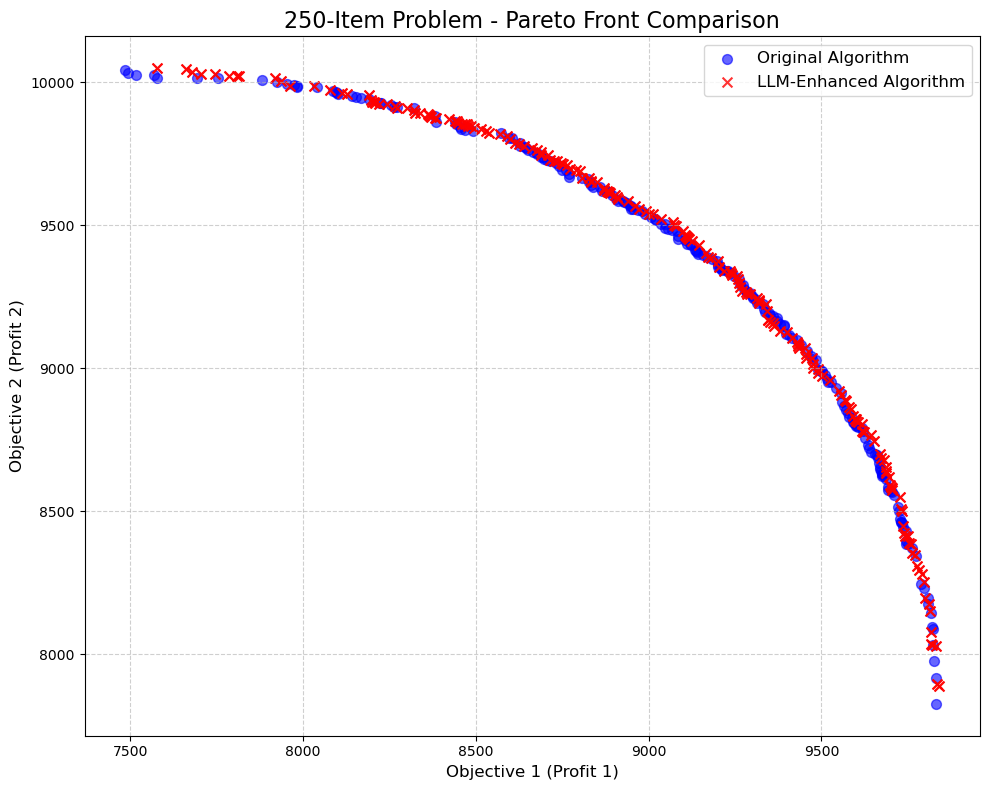


--- 500-Item Problem ---
  Original Pareto size: 369
  Enhanced Pareto size: 716
  Size improvement: 94.04%
  Original Hypervolume: 23044962.94
  Enhanced Hypervolume: 22606710.00
  Hypervolume improvement: -1.90%


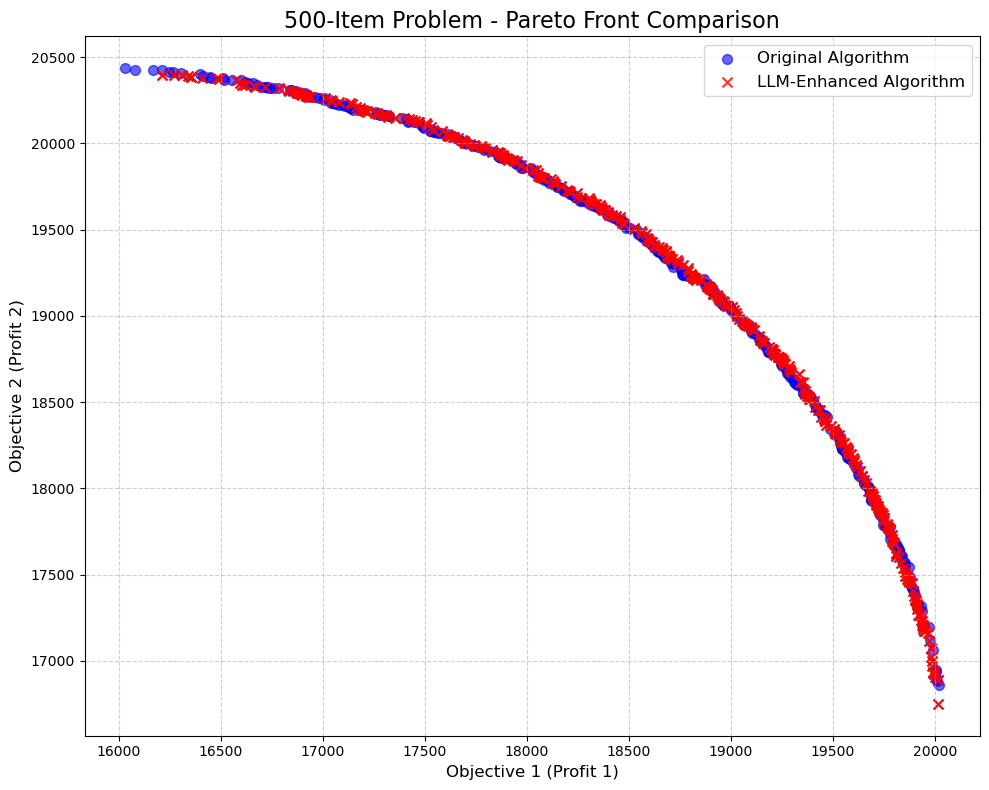


--- 750-Item Problem ---
  Original Pareto size: 552
  Enhanced Pareto size: 1084
  Size improvement: 96.38%
  Original Hypervolume: 56877706.67
  Enhanced Hypervolume: 53690671.08
  Hypervolume improvement: -5.60%


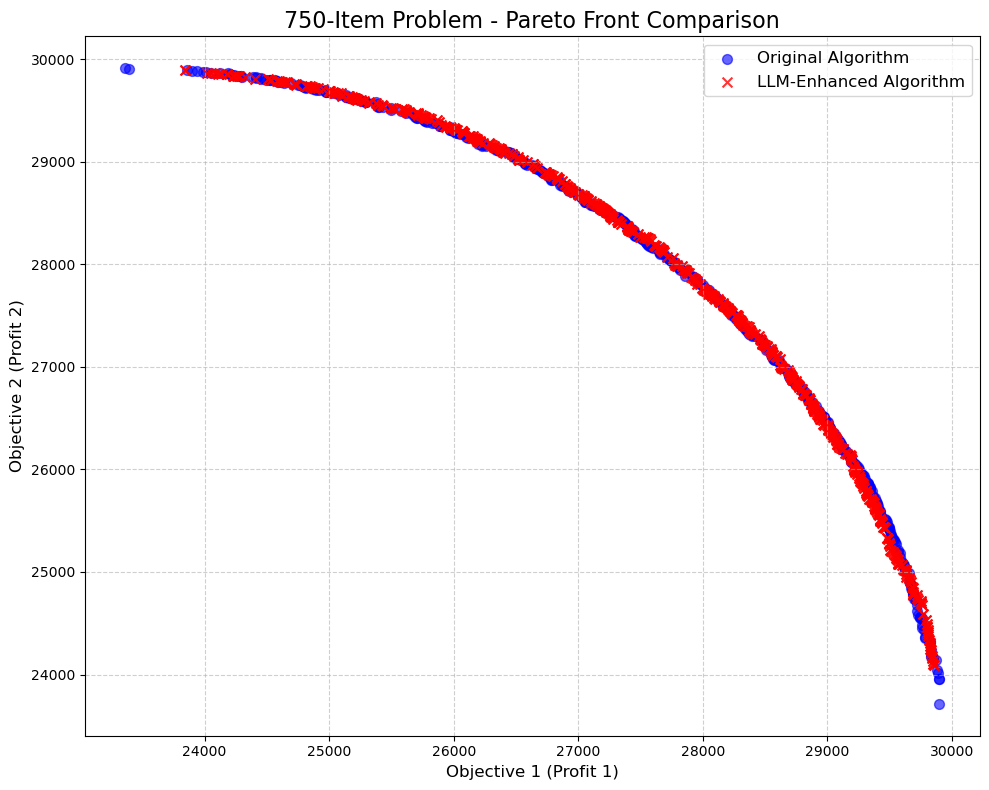


              SUMMARY OF IMPROVEMENTS
250 Items: Pareto size 84.91%, Hypervolume -1.84%
500 Items: Pareto size 94.04%, Hypervolume -1.90%
750 Items: Pareto size 96.38%, Hypervolume -5.60%

--- AVERAGE IMPROVEMENTS ---
Pareto size: 91.77%
Hypervolume: -3.12%


In [6]:
# Results comparison and analysis
import matplotlib.pyplot as plt
import numpy as np

def dominates(a, b):
    """Returns True if a dominates b (maximization for both objectives)."""
    return all(x >= y for x, y in zip(a, b)) and any(x > y for x, y in zip(a, b))

def get_true_pareto_front(points):
    """Extract the true Pareto front from a set of points"""
    pareto = []
    for i, p in enumerate(points):
        dominated = False
        for j, q in enumerate(points):
            if i != j and dominates(q, p):
                dominated = True
                break
        if not dominated:
            pareto.append(p)
    return pareto

def calculate_hypervolume(points):
    """Calculate a simplified hypervolume metric for comparison."""
    if not points:
        return 0.0
    
    # Find reference point (slightly worse than the worst point found)
    ref_x = max(p[0] for p in points) * 1.1
    ref_y = max(p[1] for p in points) * 1.1
    
    # Sort by first objective
    sorted_points = sorted(points, key=lambda p: p[0])
    
    # Calculate hypervolume using trapezoidal rule
    hv = 0.0
    for i in range(len(sorted_points) - 1):
        x1, y1 = sorted_points[i]
        x2, y2 = sorted_points[i + 1]
        hv += (x2 - x1) * (ref_y - y1)
    
    # Add last segment
    if sorted_points:
        x_last, y_last = sorted_points[-1]
        hv += (ref_x - x_last) * (ref_y - y_last)
    
    return hv

def compare_results(original_file, enhanced_file, title):
    """Compare original and enhanced results, print metrics, and plot."""
    # Read original results
    original_points = []
    with open(original_file, "r") as f:
        for line in f:
            line = line.strip()
            if line:
                try:
                    original_points.append([float(x) for x in line.split()])
                except Exception:
                    pass
    
    # Read enhanced results
    enhanced_points = []
    with open(enhanced_file, "r") as f:
        for line in f:
            line = line.strip()
            if line:
                try:
                    enhanced_points.append([float(x) for x in line.split()])
                except Exception:
                    pass
    
    # Get Pareto fronts
    original_pareto = get_true_pareto_front(original_points)
    enhanced_pareto = get_true_pareto_front(enhanced_points)
    
    # Calculate metrics
    original_size = len(original_pareto)
    enhanced_size = len(enhanced_pareto)
    size_improvement = (enhanced_size - original_size) / original_size * 100 if original_size > 0 else 0
    
    # Calculate hypervolume improvement
    original_hv = calculate_hypervolume(original_pareto)
    enhanced_hv = calculate_hypervolume(enhanced_pareto)
    hv_improvement = (enhanced_hv - original_hv) / original_hv * 100 if original_hv > 0 else 0
    
    print(f"\n--- {title} ---")
    print(f"  Original Pareto size: {original_size}")
    print(f"  Enhanced Pareto size: {enhanced_size}")
    print(f"  Size improvement: {size_improvement:.2f}%")
    print(f"  Original Hypervolume: {original_hv:.2f}")
    print(f"  Enhanced Hypervolume: {enhanced_hv:.2f}")
    print(f"  Hypervolume improvement: {hv_improvement:.2f}%")
    
    # Plot comparison
    plt.figure(figsize=(10, 8))
    
    # Plot original Pareto front
    if original_pareto:
        ox, oy = zip(*original_pareto)
        plt.scatter(ox, oy, color='blue', alpha=0.6, s=50, label="Original Algorithm")
    
    # Plot enhanced Pareto front
    if enhanced_pareto:
        ex, ey = zip(*enhanced_pareto)
        plt.scatter(ex, ey, color='red', marker='x', s=50, alpha=0.8, label="LLM-Enhanced Algorithm")
    
    plt.xlabel("Objective 1 (Profit 1)", fontsize=12)
    plt.ylabel("Objective 2 (Profit 2)", fontsize=12)
    plt.title(f"{title} - Pareto Front Comparison", fontsize=16)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
    
    return {
        "original_size": original_size,
        "enhanced_size": enhanced_size,
        "size_improvement": size_improvement,
        "original_hv": original_hv,
        "enhanced_hv": enhanced_hv,
        "hv_improvement": hv_improvement
    }

# --- MAIN EXECUTION ---

# Make sure you have run all your experiments and the result files exist.
# The enhanced files should be: 2502_Results_LLM_Enhanced.txt, etc.

print("Starting comprehensive results analysis...")

# Compare results for each instance size
results_250 = compare_results("2502_ResultsMD.txt", "2502_Results_LLM_Enhanced.txt", "250-Item Problem")
results_500 = compare_results("5002_ResultsMD.txt", "5002_Results_LLM_Enhanced.txt", "500-Item Problem")
results_750 = compare_results("7502_ResultsMD.txt", "7502_Results_LLM_Enhanced.txt", "750-Item Problem")

# Summary of improvements
print("\n======================================================")
print("              SUMMARY OF IMPROVEMENTS")
print("======================================================")
print(f"250 Items: Pareto size {results_250['size_improvement']:.2f}%, Hypervolume {results_250['hv_improvement']:.2f}%")
print(f"500 Items: Pareto size {results_500['size_improvement']:.2f}%, Hypervolume {results_500['hv_improvement']:.2f}%")
print(f"750 Items: Pareto size {results_750['size_improvement']:.2f}%, Hypervolume {results_750['hv_improvement']:.2f}%")

# Average improvements
avg_size_improvement = (results_250['size_improvement'] + results_500['size_improvement'] + results_750['size_improvement']) / 3
avg_hv_improvement = (results_250['hv_improvement'] + results_500['hv_improvement'] + results_750['hv_improvement']) / 3

print("\n--- AVERAGE IMPROVEMENTS ---")
print(f"Pareto size: {avg_size_improvement:.2f}%")
print(f"Hypervolume: {avg_hv_improvement:.2f}%")
print("======================================================")